# Recyclable Waste Material Classification

The dataset used can be found on the Hugging Face website at https://huggingface.co/datasets/garythung/trashnet/tree/main .

A GitHub repository by the original creator of the dataset is on https://github.com/garythung/trashnet .

To download the dataset locally, go to the 'Files and Versions' tab and click the download button next to 'dataset-original.zip'. The zip file will need to be uploaded to your Drive to load on this notebook.

This notebook includes code modified from https://github.com/nachi-hebbar/Transfer-Learning-ResNet-Keras and  https://github.com/KamiriTech/Loading-and-Pre-processing-Image-Datasets-in-Google-colab-

### Data Preprocessing

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tf_keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [3]:
# Splitting data into training and validation sets with 20% for validation.
dataset=tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original')
ds_train = tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original',
        validation_split=0.2,
        subset="training",
        seed=123)
ds_validation = tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original',
        validation_split=0.2,
        subset="validation",
        seed=123)

Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [4]:
# Define batch size and print labels

batch_size = 32

dataset_name = dataset
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
# Resizing and standardizing
# x = images, y = labels
size = (512, 384)

ds_train = ds_train.map(lambda x, y: (tf.image.resize(x, size), y))
ds_validation = ds_validation.map(lambda x, y: (tf.image.resize(x, size), y))

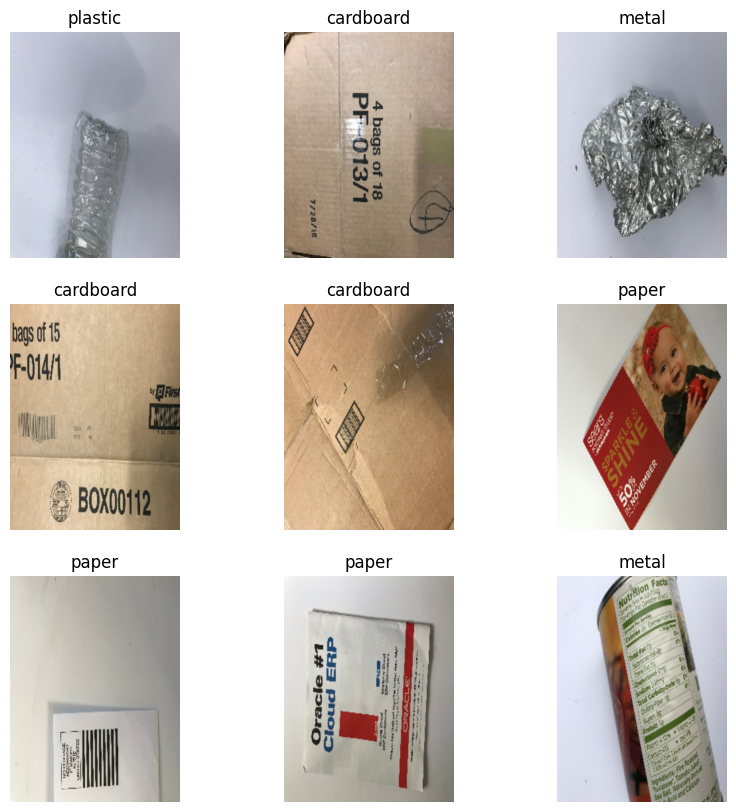

In [6]:
# Display first 9 images

plt.figure(figsize=(10, 10))
for x, y in ds_train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x[i].numpy().astype("uint8"))
    plt.title(class_names[y[i]])
    plt.axis("off")

## Testing pre-trained ResNet-50 model

In [7]:
resnet_model = tf_keras.Sequential()

pretrained_model = tf_keras.applications.ResNet50(include_top=False,
                   input_shape=(512,384,3),
                   pooling='avg', classes=6,
                   weights='imagenet') # pretrained on imagenet
for layer in pretrained_model.layers:
        layer.trainable=False # whatever resnet has learned is unchanged

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(6, activation='softmax'))



94765736/94765736 [==============================] - 6s 0us/step


In [8]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 module_wrapper (ModuleWrap  (None, 2048)              0         
 per)                                                            
                                                                 
 module_wrapper_1 (ModuleWr  (None, 512)               1049088   
 apper)                                                          
                                                                 
 module_wrapper_2 (ModuleWr  (None, 6)                 3078      
 apper)                                                          
                                                                 
Total params: 24639878 (93.99 MB)
Trainable params: 1052166 (4.01 MB)
Non-trainable params: 23587712 (89.98 MB)
__________

In [9]:
resnet_model.compile(optimizer=tf_keras.optimizers.Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [10]:
epochs=10
history = resnet_model.fit(
  ds_train,
  validation_data=ds_validation,
  epochs=epochs
)

Epoch 1/10


64/64 [==============================] - 337s 5s/step - loss: 0.7446 - accuracy: 0.7240 - val_loss: 0.4999 - val_accuracy: 0.8277
Epoch 2/10
64/64 [==============================] - 361s 6s/step - loss: 0.3284 - accuracy: 0.8902 - val_loss: 0.4229 - val_accuracy: 0.8574
Epoch 3/10
64/64 [==============================] - 350s 5s/step - loss: 0.2298 - accuracy: 0.9204 - val_loss: 0.4478 - val_accuracy: 0.8356
Epoch 4/10
64/64 [==============================] - 318s 5s/step - loss: 0.1625 - accuracy: 0.9505 - val_loss: 0.3607 - val_accuracy: 0.8752
Epoch 5/10
64/64 [==============================] - 327s 5s/step - loss: 0.1328 - accuracy: 0.9575 - val_loss: 0.4018 - val_accuracy: 0.8495
Epoch 6/10
64/64 [==============================] - 320s 5s/step - loss: 0.0748 - accuracy: 0.9773 - val_loss: 0.3704 - val_accuracy: 0.8673
Epoch 7/10
64/64 [==============================] - 261s 4s/step - loss: 0.0594 - accuracy: 0.9857 - val_loss: 0.3734 - val_accuracy: 0.8832
Epoch 8/10


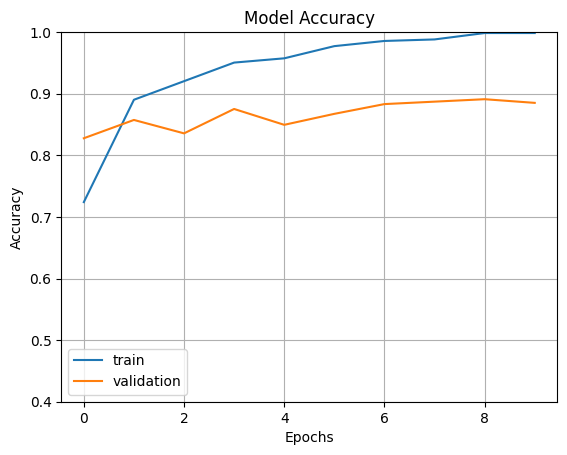

In [11]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

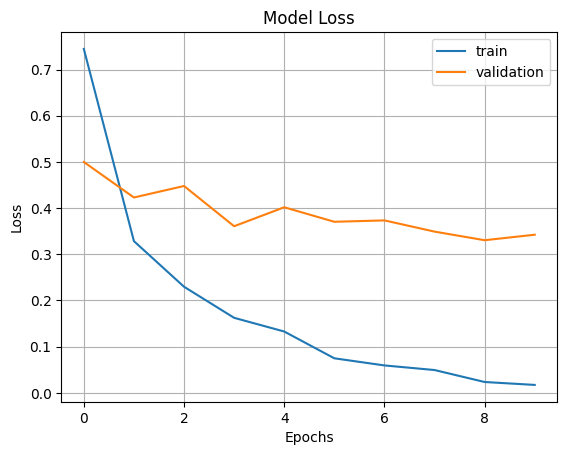

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [13]:
import os

img_height, img_width = 512, 384

folder_path = 'dataset-original/cardboard'

image_files = os.listdir(folder_path)

# Ensure the folder is not empty
if not image_files:
    print("Error: No images found in the folder.")
else:
    # Select the first image in the folder
    image_path = os.path.join(folder_path, image_files[0])

    # Read the image
    image = cv2.imread(image_path)

    # Check if image was loaded successfully
    if image is None:
        print(f"Error: Unable to load image {image_path}")
    else:
        # Resize the image
        image_resized = cv2.resize(image, (img_width, img_height))

        # Expand dimensions to match model input format
        image = np.expand_dims(image_resized, axis=0)

        # Print the shape
        print("Image shape:", image.shape)

Error: Unable to load image dataset-original/cardboard\.DS_Store


In [ ]:
prediction=resnet_model.predict(image)
print(prediction)

NameError: name 'resnet_model' is not defined

In [ ]:
output_class=class_names[np.argmax(prediction)]
print("The predicted class is", output_class)

The predicted class is cardboard


### ignore leftover testing in colab

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import streamlit as st


@st.cache(allow_output_mutation=True)
def load_model():
  model=tf.keras.models.load_model('/content/final_model.hdf5')
  return model
with st.spinner('Model is being loaded..'):
  model=load_model()

st.write("""
         # Recyclable Waste Classification
         """
         )

file = st.file_uploader("Please upload an image file", type=["jpg", "png"])

from PIL import Image, ImageOps

st.set_option('deprecation.showfileUploaderEncoding', False)
def import_and_predict(image_data, model):

        size = (180,180)
        image = ImageOps.fit(image_data, size, Image.ANTIALIAS)
        image = np.asarray(image)
        img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #img_resize = (cv2.resize(img, dsize=(75, 75),    interpolation=cv2.INTER_CUBIC))/255.

        img_reshape = img[np.newaxis,...]

        prediction = model.predict(img_reshape)

        return prediction
if file is None:
    st.text("Please upload an image file")
else:
    image = Image.open(file)
    st.image(image, use_column_width=True)
    predictions = import_and_predict(image, model)
    score = tf.nn.softmax(predictions[0])
    st.write(prediction)
    st.write(score)
    print(
    "This image is most likely {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

In [ ]:
!pip install pyngrok

In [ ]:
!ngrok authtoken #Insert Authentication Token here, obtained from Ngrok